Analysis notebook for the data collection period for summer 2025 (period 02).
<br>
Here we:

- Load merged & tagged event-level dataframe.
- Use HE scale and perform trigger02 efficiency cut (OJO CON HE SCALE, NECESITAMOS MISMO PROCESAMIENTO DE KR MAP).
- Select $nS2=1$ for fiducial events (electron-like).
- Update summary with event counter per run.
- Plot.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import bckg_functions as bf
from libs import plotting_tools as pt

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# Styling Plot
pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

In [2]:
# --------------------
# 1. FILES INFORMATION
# --------------------
# Filenames tag
VERSION_TAG = 'p2'

# Directory
INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/'

# ------------
# 2. SELECTION
# ------------
# HE scale correction
M_HE_SCALE = 4.80e-06
B_HE_SCALE = 0.0094         # in [MeV]
DEP_CORRECTION = 0.0695     # in [MeV], ajustando al DEP

# ----- Trigger 2 Efficiency Cut ----- #
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5        # in [MeV]

# -----------------
# 3. PLOT SETTINGS
# -----------------
# From merged_corr_time.txt
RAS_OFF_CORRECTED_TIME = 697798.6254801187      # in [s]
RAS_ON_CORRECTED_TIME  = 3485614.533823055      # in [s]

# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

### Load Runs & Summary Information

In [3]:
# ----- Main Directories ----- #
RUNS_INFO_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/'
SUMMARY_DIR   = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/'

# ----- Filenames ----- #
SUMMARY_NAME = f'summary_{VERSION_TAG}_processed.csv'

# ----- Load Dataframes ----- #
RUNS_INFO_DF = pd.read_csv(os.path.join(RUNS_INFO_DIR, f'runs_information.csv'))
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()

SUMMARY_DF   = pd.read_csv(os.path.join(SUMMARY_DIR, SUMMARY_NAME))
SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()
SUMMARY_DF.sort_values(by='Run_ID', inplace=True)

#### Which runs will you analyze?

Sometimes we'll analyze by _data period_, sometimes by _detector condition_ or sometimes everything together

In [4]:
# ----- Configuration ----- #
DATA_PERIOD = 2                 # Options: 1, 2
DETECTOR_CONDITION = None       # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'

In [5]:
selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

runs_in_summary = SUMMARY_DF['Run_ID'].unique()
print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary")
selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

if DATA_PERIOD is not None:
    print(f"→ Period == {DATA_PERIOD}")
    # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
    selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

if DETECTOR_CONDITION is not None:
    print(f"→ Condition == '{DETECTOR_CONDITION}'")
    selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for analysis:\n{RUNS_TO_ANALYZE}")

EVT_COUNT_PER_RUN = {run: {'Trg2_Cut': 0, 'nElectrons': 0, 'S2_Cut': 0, 'nElectron_Fiducial': 0} for run in RUNS_TO_ANALYZE}
print(f"\nDictionary for new event counts initialized.")

→ Must be one of the 67 runs in the summary
→ Period == 2

Selected 67 runs for analysis:
[15609 15614 15615 15616 15617 15618 15619 15621 15622 15623 15624 15625
 15626 15627 15632 15633 15634 15635 15636 15637 15639 15640 15642 15643
 15644 15645 15647 15648 15649 15650 15655 15656 15657 15658 15659 15669
 15670 15671 15672 15673 15675 15676 15681 15682 15687 15688 15689 15693
 15694 15695 15696 15697 15698 15699 15700 15701 15709 15724 15729 15730
 15731 15732 15733 15734 15735 15736 15737]

Dictionary for new event counts initialized.


### Load Merged/Tagged Dataframes

In [6]:
# Dictionary with dataframes for RAS on/off 
DATAFRAMES = {
                'ras_off': {'duration': RAS_OFF_CORRECTED_TIME, 'processed': pd.DataFrame(), 'inclusive': pd.DataFrame(), 'fiducial': pd.DataFrame()},
                'ras_on' : {'duration': RAS_ON_CORRECTED_TIME,  'processed': pd.DataFrame(), 'inclusive': pd.DataFrame(), 'fiducial': pd.DataFrame()}
}

In [7]:
for ras_status in ['ras_off', 'ras_on']:

    print(f"Loading for {ras_status.upper()}:")

    if ras_status == 'ras_off':
        filename = f'merged_tagged_runs_castle_closed_{VERSION_TAG}_final.h5'
    elif ras_status == 'ras_on':
        filename = f'merged_tagged_runs_castle_closed_RAS_{VERSION_TAG}_final.h5'

    df_processed = pd.read_hdf(os.path.join(INPUT_DIR, filename), key='Events')
    print(f"→ Processed dataframe loaded with {df_processed['global_event'].nunique()} events")
    DATAFRAMES[ras_status]['processed'] = df_processed

Loading for RAS_OFF:


→ Processed dataframe loaded with 197775 events
Loading for RAS_ON:
→ Processed dataframe loaded with 939944 events


# Trigger02 Cut: or energy window

In [8]:
for ras_status in ['ras_off', 'ras_on']:

    print(f"Trigger02 cut for {ras_status.upper()}")
    df_temp = DATAFRAMES[ras_status]['processed']

    # Convert from [pe] to [MeV] using HE scale
    df_temp = bf.energy_pe_to_mev(df_temp, slope=M_HE_SCALE, intercept=B_HE_SCALE - DEP_CORRECTION, input_column='E_evt_pe', output_column='E_evt_mev')

    # Trigger2 efficiency cut
    df_temp = df_temp[df_temp['E_evt_mev'] >= TRG2_THRESHOLD].copy()

    # Update EVT_COUNT_PER_RUN
    for run_id in df_temp['run_number'].unique():

        run_mask = (df_temp['run_number'] == run_id)
        after_trg2_ids = df_temp.loc[run_mask, 'global_event'].unique()
        EVT_COUNT_PER_RUN[run_id]['Trg2_Cut'] = len(after_trg2_ids)

    # Update dataframe
    DATAFRAMES[ras_status]['processed'] = df_temp    

Trigger02 cut for RAS_OFF
Trigger02 cut for RAS_ON


# Inclusive Electrons

In [9]:
for ras_status in ['ras_off', 'ras_on']:

    print(f"Inclusive electrons for {ras_status.upper()}")
    df_temp = DATAFRAMES[ras_status]['processed']

    # Select only electron-like particles
    df_temp = df_temp[df_temp['particle'] == 'electron'].copy()

    # Update EVT_COUNT_PER_RUN
    for run_id in df_temp['run_number'].unique():

        run_mask = (df_temp['run_number'] == run_id)
        inclusive_ids = df_temp.loc[run_mask, 'global_event'].unique()
        EVT_COUNT_PER_RUN[run_id]['nElectrons'] = len(inclusive_ids)

    # Update dataframe
    DATAFRAMES[ras_status]['inclusive'] = df_temp

Inclusive electrons for RAS_OFF
Inclusive electrons for RAS_ON


# Fiducial Electrons

### $nS2=1$

In [10]:
for ras_status in ['ras_off', 'ras_on']:

    print(f"Fiducial electrons for {ras_status.upper()}")
    df_temp = DATAFRAMES[ras_status]['inclusive']

    # nS2 = 1
    df_temp = df_temp[df_temp['nS2'] == 1].copy()

    # Update EVT_COUNT_PER_RUN
    for run_id in df_temp['run_number'].unique():

        run_mask = (df_temp['run_number'] == run_id)
        after_s2_ids = df_temp.loc[run_mask, 'global_event'].unique()
        EVT_COUNT_PER_RUN[run_id]['S2_Cut'] = len(after_s2_ids)

    # Update dataframe
    DATAFRAMES[ras_status]['fiducial'] = df_temp

Fiducial electrons for RAS_OFF
Fiducial electrons for RAS_ON


### Fiducial Volume

In [11]:
for ras_status in ['ras_off', 'ras_on']:

    print(f"Fiducial electrons for {ras_status.upper()}")
    df_temp = DATAFRAMES[ras_status]['fiducial']

    # Fiducial volume
    df_temp = df_temp[df_temp['region'] == 'fiducial'].copy()

    # Update EVT_COUNT_PER_RUN
    for run_id in df_temp['run_number'].unique():

        run_mask = (df_temp['run_number'] == run_id)
        fiducial_ids = df_temp.loc[run_mask, 'global_event'].unique()
        EVT_COUNT_PER_RUN[run_id]['nElectron_Fiducial'] = len(fiducial_ids)

    # Update dataframe
    DATAFRAMES[ras_status]['fiducial'] = df_temp

Fiducial electrons for RAS_OFF
Fiducial electrons for RAS_ON


# Update Summary

In [16]:
# Convert dictionary to DataFrame
SELECT_SUMMARY_DF = pd.DataFrame.from_dict(EVT_COUNT_PER_RUN, orient='index')
SELECT_SUMMARY_DF.rename_axis("Run_ID", inplace=True)
SELECT_SUMMARY_DF.reset_index(inplace=True)
SELECT_SUMMARY_DF

,Run_ID,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15609,13331,1735,1548,259
1,15614,13265,1759,1548,232
2,15615,13957,1872,1650,260
3,15616,14385,1898,1650,240
4,15617,14673,1891,1648,256
...,...,...,...,...,...
62,15733,13850,1738,1469,184
63,15734,13480,1813,1505,173
64,15735,13906,1777,1508,185
65,15736,15107,1840,1539,181


NO confío en la forma en que estoy actualizando los summaries
<br>
_PILAS!_

In [17]:
# Set 'Run_ID' as index in both dataframes
summary_with_index = SUMMARY_DF.set_index('Run_ID')
select_with_index  = SELECT_SUMMARY_DF.set_index('Run_ID')

# Update original summary with new selection counts
summary_with_index.update(select_with_index)

# Reset index to turn 'Run_ID' back into a column
UPDATED_SUMMARY_DF = summary_with_index.reset_index()
UPDATED_SUMMARY_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,Z_Positive,S1_Cut,Clean_Events
0,15609,79563,1.753150e+09,167.3591,28168,8392,27865,20667,17703,17695
1,15614,81279,1.753244e+09,171.2587,28543,8472,28225,20811,17664,17656
2,15615,86302,1.753328e+09,174.9253,30165,9046,29767,21927,18634,18629
3,15616,86146,1.753414e+09,174.7854,30386,8635,30124,22198,18919,18907
4,15617,88041,1.753502e+09,175.5444,31274,8983,31052,22945,19591,19584
...,...,...,...,...,...,...,...,...,...,...
62,15733,86919,1.758939e+09,175.0674,30475,10027,30144,22120,18663,18657
63,15734,85790,1.759026e+09,176.3823,29837,9598,29513,21813,18275,18261
64,15735,87451,1.759113e+09,175.5591,30547,9958,30193,22198,18810,18801
65,15736,93376,1.759204e+09,181.1218,32622,10506,32243,23718,20280,20272


In [18]:
# UPDATED_SUMMARY_DF.to_csv(os.path.join(SUMMARY_DIR, f'summary_{VERSION_TAG}_updated.csv'))
print('Done! Summary updated in:', os.path.join(SUMMARY_DIR, f'summary_{VERSION_TAG}_updated.csv'))

Done! Summary updated in: /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_p2_updated.csv


# Plots

Aquí tengo varios plots por actualizar porque por ahora me enfoco en los del paper de Radon

In [28]:
for ras_status in ['ras_off', 'ras_on']:

    print(f"--- {ras_status.upper()} ---")
    duration = DATAFRAMES[ras_status]['duration']
    df_temp  = DATAFRAMES[ras_status]['fiducial']

    print(f"Number of fiducial electrons: {df_temp['global_event'].nunique()}")
    print(f"Corrected Time: {duration} s\n")

--- RAS_OFF ---
Number of fiducial electrons: 2663
Corrected Time: 697798.6254801187 s

--- RAS_ON ---
Number of fiducial electrons: 9917
Corrected Time: 3485614.533823055 s



## Inclusive (RAS: ON)

### XY Map 

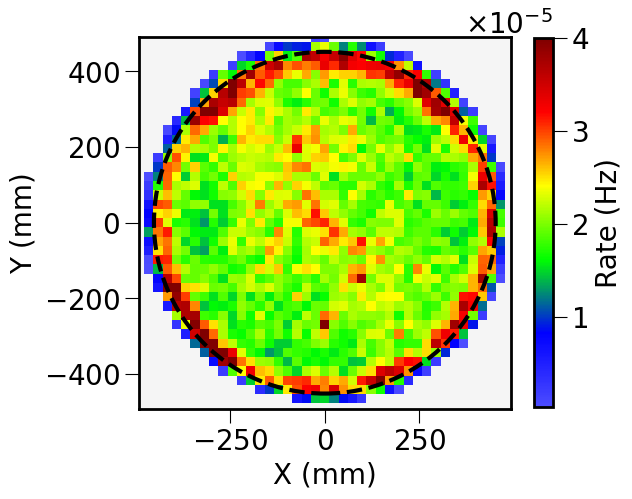

In [32]:
# Global
n_bins = 50

# Dataframe
data = DATAFRAMES['ras_on']['inclusive']
duration = DATAFRAMES['ras_on']['duration']

# Variables
X = data['X_bary'].unique()
Y = data['Y_bary'].unique()

# 2D histogram: normalized by corrected DAQ data taking time
XY_hit_map, ex, ey = pt.mapping(X, Y, xy_bins=n_bins, pos=True)
XY_rate            = XY_hit_map / duration                          # Normalized to rate      
XY_rate            = np.ma.masked_where(XY_rate == 0, XY_rate)      # Zero values masked
XY_rate            = np.clip(XY_rate, 0, 4e-5)

# ----- Plotting ----- #
plt.figure(figsize=(6, 6))
im = plt.pcolormesh(ex, ey, XY_rate.T, cmap=pt.custom_hsv, shading='auto')
cbar = plt.colorbar(im, label='Rate (Hz)', shrink=0.80)
cbar.formatter.set_powerlimits((-3, 3))

plt.xlabel('X (mm)')
plt.xlim(-pt.N100_rad, pt.N100_rad)
plt.ylabel('Y (mm)')
plt.ylim(-pt.N100_rad, pt.N100_rad)

# R-lim
plt.gca().add_patch(pt.plot_circle(R_UP, LINESTYLE='--'))
plt.gca().set_aspect('equal', adjustable='box')
plt.gca().set_facecolor("whitesmoke")
# plt.tight_layout()
plt.show()

## Inclusive/Fiducial (RAS:ON)

### Z Distribution

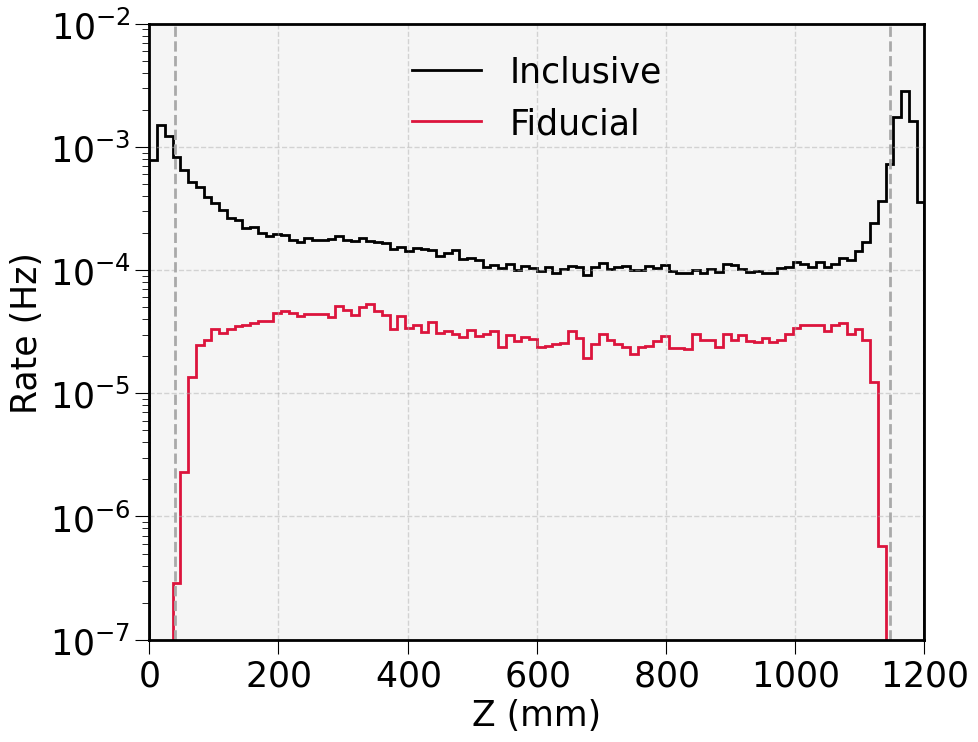

In [42]:
# Global
n_bins = 100

# Dataframes
INCL_DF = DATAFRAMES['ras_on']['inclusive']
FIDU_DF = DATAFRAMES['ras_on']['fiducial']

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(INCL_DF['Z_bary'].unique(), bins=n_bins, range=(0, 1200))

for i, dataframe in enumerate([INCL_DF, FIDU_DF]):

    # Variable
    Z_evt = dataframe['Z_bary'].unique()

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    rate = counts / DATAFRAMES['ras_on']['duration']    # in [Hz]

    # Labels
    if i == 0: label = 'Inclusive'
    else:      label = 'Fiducial'

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=2.0, ec=pt.hist_colors[i % len(pt.hist_colors)])

# Lines
plt.axvline(x=Z_LOW, c='darkgray', ls='--')
plt.axvline(x=Z_UP, c='darkgray', ls='--')

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper center', framealpha=0)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### $R^{2}$ Distribution

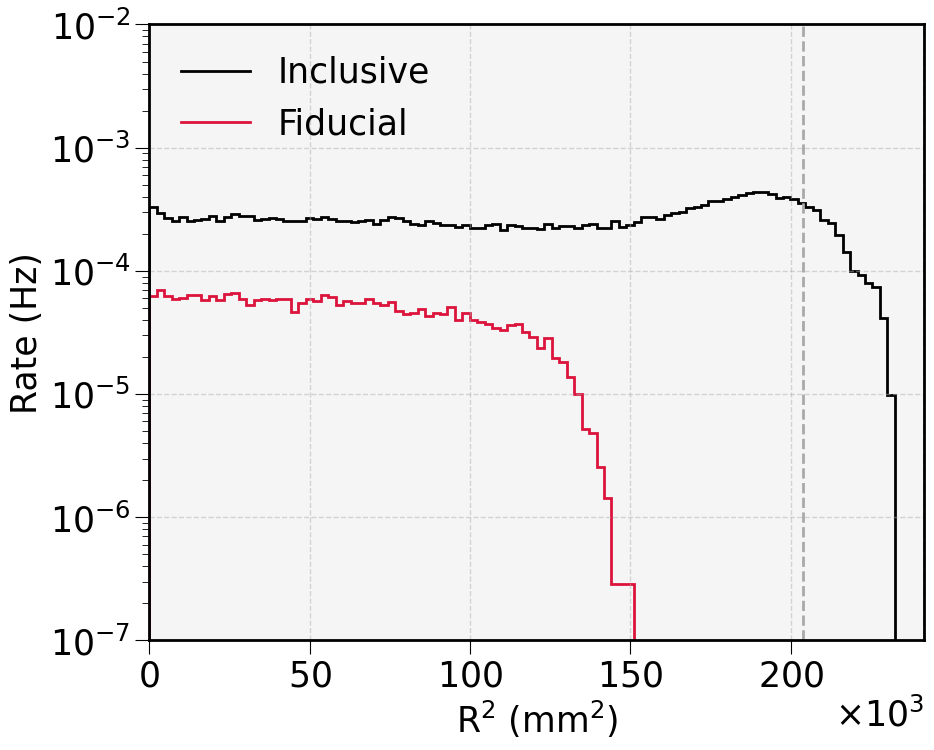

In [12]:
# Global
n_bins = 100

# Dataframes
INCL_DF = DATAFRAMES['ras_on']['inclusive']
FIDU_DF = DATAFRAMES['ras_on']['fiducial']

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
# Variables
X_evt = INCL_DF['X_bary'].unique()
Y_evt = INCL_DF['Y_bary'].unique()
R2_evt = X_evt**2 + Y_evt**2
_, plot_edges = np.histogram(R2_evt, bins=n_bins)

for i, dataframe in enumerate([INCL_DF, FIDU_DF]):

    # Variable
    X = dataframe['X_bary'].unique()
    Y = dataframe['Y_bary'].unique()
    R2 = X**2 + Y**2

    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)
    rate = counts / DATAFRAMES['ras_on']['duration']    # in [Hz]

    # Labels
    if i == 0: label = 'Inclusive'
    else:      label = 'Fiducial'

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=2.0, ec=pt.hist_colors[i % len(pt.hist_colors)])

# Lines
plt.axvline(x=R_UP**2, c='darkgray', ls='--')
plt.axvline(x=pt.N100_rad**2, c='darkgray', ls='--')

# ----- Styling ----- #
plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
plt.xlim(0, pt.N100_rad**2)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.yscale('log')
plt.legend(loc='upper left', framealpha=0)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
plt.show()

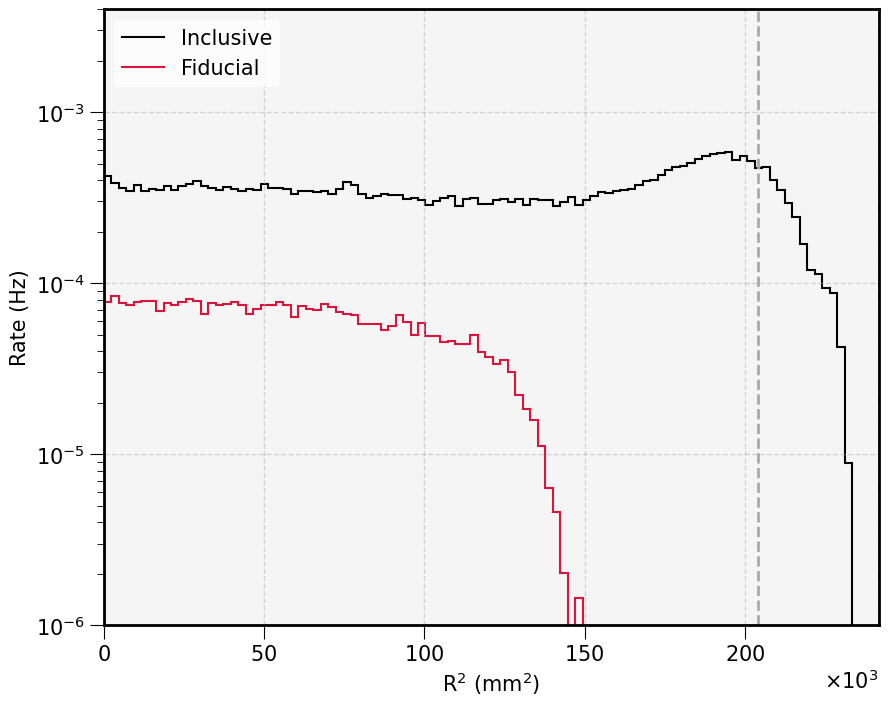

In [75]:
# Global
n_bins = 100

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
# Dataframe
data = ELEC_INCL_RAS_ON_DF.copy()

# Variables
X_evt = data['X_bary'].unique()
Y_evt = data['Y_bary'].unique()
R2_evt = X_evt**2 + Y_evt**2
_, plot_edges = np.histogram(R2_evt, bins=n_bins)

for i, dataframe in enumerate([ELEC_INCL_RAS_ON_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    X = dataframe['X_bary'].unique()
    Y = dataframe['Y_bary'].unique()
    R2 = X**2 + Y**2

    # Histogram
    counts, bin_edges = np.histogram(R2, bins=plot_edges)
    rate = counts / (RAS_ON_CORRECTED_TIME)  # in [Hz]

    # Labels
    if i == 0:
        label = 'Inclusive'
    else:
        label = 'Fiducial'

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

# Lines
plt.axvline(x=R_UP**2, c='darkgray', ls='--')
plt.axvline(x=pt.N100_rad**2, c='darkgray', ls='--')

# ----- Styling ----- #
plt.xlabel(r'R$^{2}$ (mm$^{2}$)')
plt.xlim(0, pt.N100_rad**2)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-6, 4e-3)
plt.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
plt.yscale('log')
plt.legend(loc='upper left')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/R2_Bckg_Inclusive_Fiducial.pdf')
plt.show()

### E Distribution

Center of the DEP bin: 1.6625 MeV
Shift value: 0.0695 MeV
Inclusive in range: counts = 90571, corr. time = 3485614.53 s | Rate = 0.0260 Hz
Fiducial in range: counts = 9915, corr. time = 3485614.53 s | Rate = 0.0028 Hz


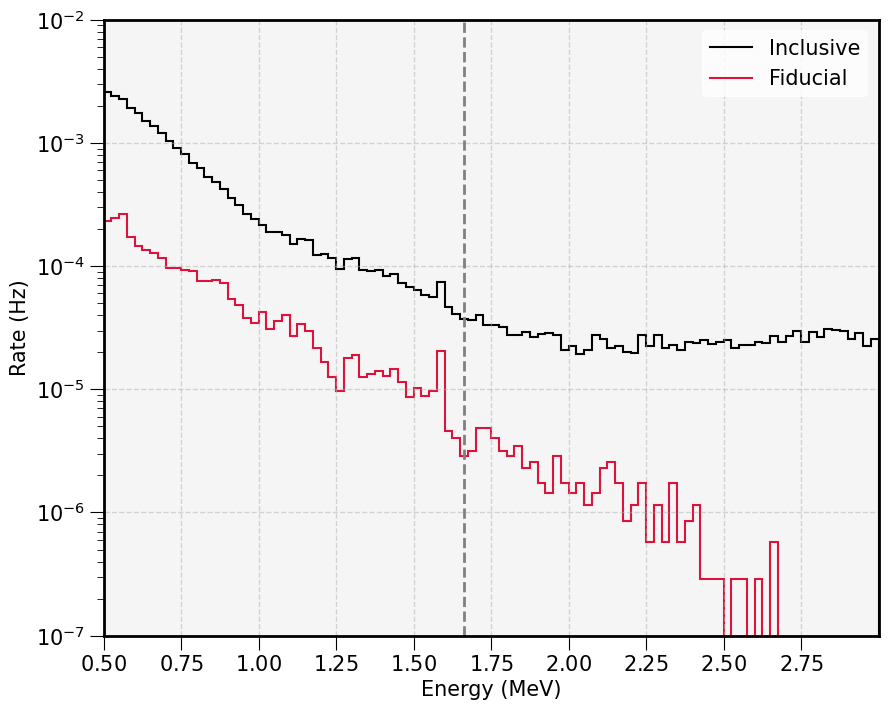

In [ ]:
# Global
n_bins = 100
DEP_VALUE = 1.593       # MeV

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_INCL_RAS_ON_DF['E_evt_mev'].unique(), bins=n_bins, range=(0.5, 3))

# ----- Shifting the Histogram ----- #
# Use the "Fiducial" data that includes DEP peak 
E_counts_fid, _ = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=plot_edges)
# Mask around DEP peak
mask = (plot_edges[:-1] >= 1.55) & (plot_edges[:-1] <= 1.75)  
bin_centers = (plot_edges[:-1] + plot_edges[1:]) / 2
# Find the bin with the highest count in the specified range
peak_bin_index  = np.argmax(E_counts_fid[mask])
peak_bin_center = bin_centers[mask][peak_bin_index]
print(f"Center of the DEP bin: {peak_bin_center:.4f} MeV")
shift_value = peak_bin_center - DEP_VALUE
print(f"Shift value: {shift_value:.4f} MeV")

for i, dataframe in enumerate([ELEC_INCL_RAS_ON_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    E_evt = dataframe['E_evt_mev'].unique() - shift_value

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    rate = counts / (RAS_ON_CORRECTED_TIME)  # in [Hz]

    # Labels
    if i == 0:
        label = 'Inclusive'
    else:
        label = 'Fiducial'

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {RAS_ON_CORRECTED_TIME:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

# Lines
plt.axvline(peak_bin_center, c='gray', ls='--')
plt.axvline(x=DEP_VALUE, c='gray', ls='--')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()

What are those _high energy_ events?! Yep those above $2.6$ MeV...

In [65]:
over_2_6_MeV_ids = ELEC_INCL_RAS_ON_DF.loc[ELEC_INCL_RAS_ON_DF['E_evt_mev'] >= 2.6, 'global_event'].unique()
over_2_6_MeV_df = ELEC_INCL_RAS_ON_DF.loc[ELEC_INCL_RAS_ON_DF['global_event'].isin(over_2_6_MeV_ids)].copy()

In [38]:
over_2_6_MeV_df

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,run_number,global_event,particle,region,E_evt_mev
2783,19224,26,5.455293e+05,2430,-19.738224,41.712058,641.697165,566.536940,742.304832,488.068255,...,1,1,558.804504,710.183553,3184,15625,2668,electron,tube,2.627941
2945,128977,36,1.017441e+06,7033,-93.362034,-0.138485,1182.809113,1164.532524,1201.831973,492.737969,...,1,1,253.671021,254.136011,7673,15625,2823,electron,cathode,4.893115
4497,1280169,25,5.849150e+05,1927,186.288550,-127.963307,278.428532,232.600987,325.284007,494.520987,...,1,1,484.453552,771.969892,2680,15625,4309,electron,tube,2.816992
4929,1605515,29,6.299369e+05,2371,345.482975,-73.429395,419.626082,374.786659,470.815608,495.788152,...,1,1,538.642456,794.186040,3236,15625,4729,electron,tube,3.033097
7226,1205928,26,5.566696e+05,1837,228.166937,-156.800447,200.617417,117.246317,289.042886,494.520987,...,1,1,431.895905,754.976870,2618,15625,6948,electron,tube,2.681414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000364,317175,25,5.927513e+05,2978,258.307199,-106.568080,947.326926,348.211643,1094.843583,498.571751,...,1,3,50.581512,75.083257,4820,15737,935341,electron,tube,3.536289
1000516,474465,25,5.743555e+05,2321,-211.806788,-256.676756,1185.960714,1168.719449,1202.574468,489.914917,...,1,1,737.726318,738.024051,3476,15737,935482,electron,cathode,2.766306
1001258,1235680,32,5.571820e+05,2184,13.784194,-38.340655,1186.023188,1168.042694,1205.437617,490.317200,...,1,1,746.278870,746.533412,3372,15737,936167,electron,cathode,2.683874
1002634,864191,26,6.399096e+05,2250,-6.411376,-24.019190,384.850940,323.278504,453.965083,498.469725,...,1,1,512.540344,796.178204,2980,15737,937423,electron,tube,3.080966


## RAS ON/OFF

### Z Distribution

RAS: off in range: counts = 3366, corr. time = 697798.63 s | Rate = 0.0048 Hz
RAS: on in range: counts = 12570, corr. time = 3485614.53 s | Rate = 0.0036 Hz


/tmp/ccortesp/ipykernel_266988/2815506879.py:38: RuntimeWarning: divide by zero encountered in divide
  Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off
/tmp/ccortesp/ipykernel_266988/2815506879.py:38: RuntimeWarning: invalid value encountered in divide
  Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off


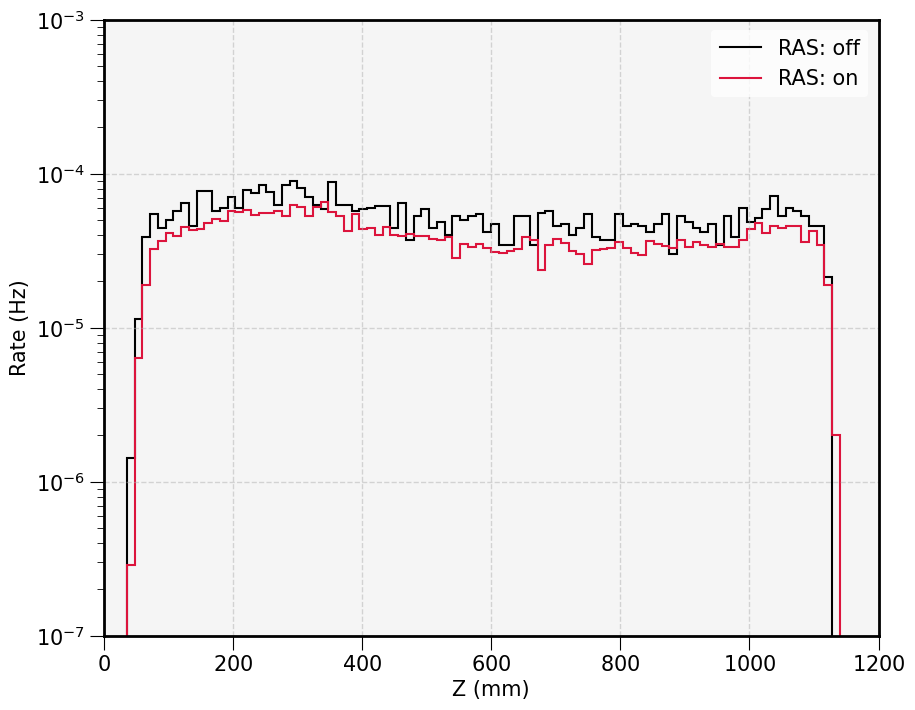

In [76]:
# Global
n_bins = 100

# Storage
Z_ras_on_off_hist = {}
rate_ras_on  = []
rate_ras_off = []

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_FIDU_RAS_ON_DF['Z_bary'].unique(), bins=n_bins, range=(0, 1200))

for i, dataframe in enumerate([ELEC_FIDU_RAS_OFF_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    Z_evt = dataframe['Z_bary'].unique()

    # Histogram
    counts, bin_edges = np.histogram(Z_evt, bins=plot_edges)
    corr_time = RAS_OFF_CORRECTED_TIME if i == 0 else RAS_ON_CORRECTED_TIME
    rate = counts / (corr_time)  # in [Hz]

    # Labels
    if i == 0:
        label = 'RAS: off'
        rate_ras_off = rate
    else:
        label = 'RAS: on'
        rate_ras_on = rate

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {corr_time:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

Z_ras_on_off_hist['bin_edges'] = bin_edges
Z_ras_on_off_hist['counts'] = rate_ras_on / rate_ras_off

# ----- Styling ----- #
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Rate (Hz)')
plt.ylim(1e-7, 1e-3)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_RAS_On_Off_Comparison.pdf')
plt.show()

Let's see the rate of both dataframes!

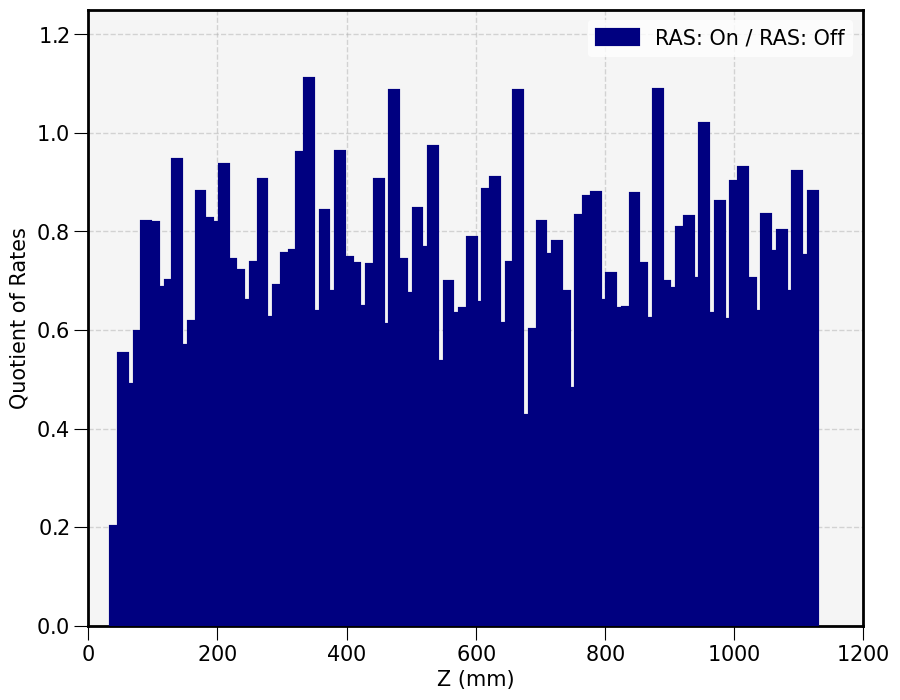

In [95]:
# Filter out NaN/Inf values
valid_counts = np.isfinite(Z_ras_on_off_hist['counts'])
filtered_counts = Z_ras_on_off_hist['counts'][valid_counts]
filtered_bin_edges = Z_ras_on_off_hist['bin_edges'][:-1][valid_counts]
bin_width = Z_ras_on_off_hist['bin_edges'][1] - Z_ras_on_off_hist['bin_edges'][0]

# ----- Plotting ----- #
plt.bar(filtered_bin_edges, filtered_counts, width=bin_width, 
       align='edge', label='RAS: On / RAS: Off', color='navy', edgecolor='navy', zorder=3)

# Styling
plt.xlabel('Z (mm)')
plt.xlim(0, 1200)
plt.ylabel('Quotient of Rates')
plt.ylim(0, 1.25)
# plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Z_Bckg_RAS_On_Off_Quotient.pdf')
plt.show()

### E Distribution

Center of the DEP bin: 1.68
Shift value: 0.08 MeV
RAS: off in range: counts = 2621, corr. time = 697798.63 s | Rate = 0.0038 Hz
RAS: on in range: counts = 9731, corr. time = 3485614.53 s | Rate = 0.0028 Hz


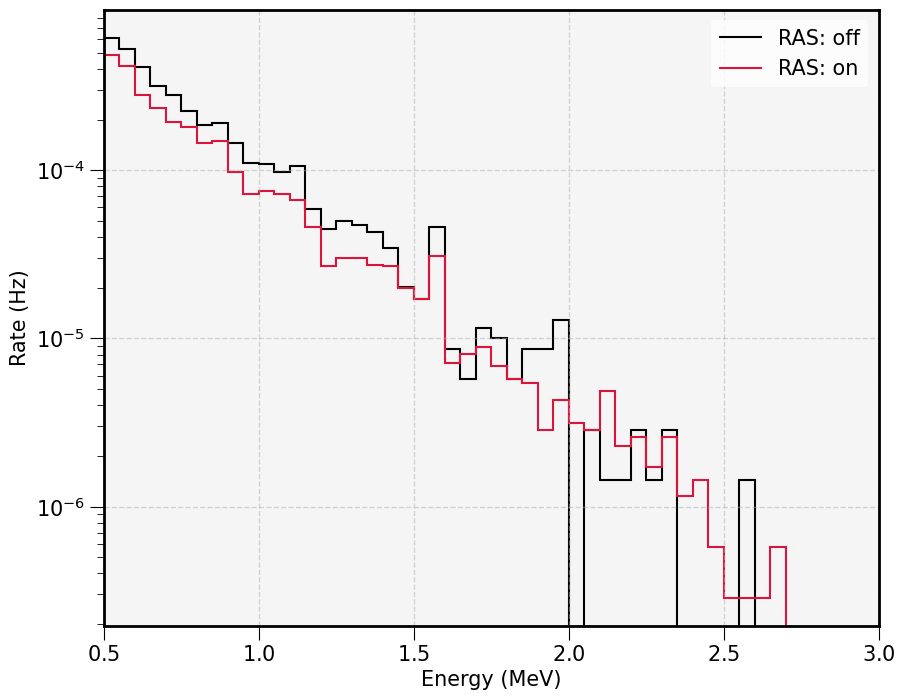

In [59]:
# Global
n_bins = 50
DEP_VALUE = 1.6       # MeV

# Storage
E_ras_on_off_hist = {}
rate_ras_on  = []
rate_ras_off = []

# ----- Define the Binning ----- #
# Use the "Inclusive" region to define the binning
_, plot_edges = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=n_bins, range=(0.5, 3))

# ----- Shifting the Histogram ----- #
# Use the "Fiducial" data that includes DEP peak 
E_counts_fid, _ = np.histogram(ELEC_FIDU_RAS_ON_DF['E_evt_mev'].unique(), bins=plot_edges)
# Mask around DEP peak
mask = (plot_edges[:-1] >= 1.55) & (plot_edges[:-1] <= 1.75)  
bin_centers = (plot_edges[:-1] + plot_edges[1:]) / 2
# Find the bin with the highest count in the specified range
peak_bin_index  = np.argmax(E_counts_fid[mask])
peak_bin_center = bin_centers[mask][peak_bin_index]
print(f"Center of the DEP bin: {peak_bin_center:.2f}")
shift_value = peak_bin_center - DEP_VALUE
print(f"Shift value: {shift_value:.2f} MeV")

for i, dataframe in enumerate([ELEC_FIDU_RAS_OFF_DF, ELEC_FIDU_RAS_ON_DF]):

    # Variable
    E_evt = dataframe['E_evt_mev'].unique() - shift_value

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    corr_time = RAS_OFF_CORRECTED_TIME if i == 0 else RAS_ON_CORRECTED_TIME
    rate = counts / (corr_time)  # in [Hz]

    # Labels
    if i == 0:
        label = 'RAS: off'
        rate_ras_off = rate
    else:
        label = 'RAS: on'
        rate_ras_on = rate

    print(f"{label} in range: counts = {counts.sum()}, corr. time = {corr_time:.2f} s | Rate = {rate.sum():.4f} Hz")

    # ----- Plotting ----- #
    plt.stairs(rate, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=pt.hist_colors[i % len(pt.hist_colors)])

E_ras_on_off_hist['bin_edges'] = bin_edges
E_ras_on_off_hist['counts'] = rate_ras_off - rate_ras_on

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.ylabel('Rate (Hz)')
# plt.ylim(1e-7, 1e-3)
plt.yscale('log')
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_RAS_On_Off_Comparison.pdf')
plt.show()

And the quotient...

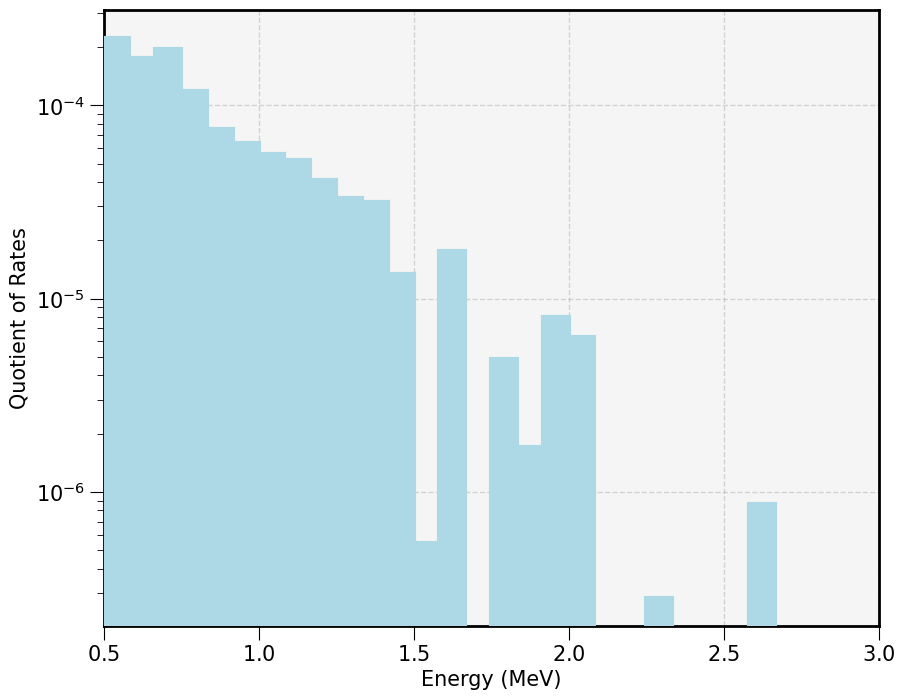

In [58]:
# Filter out NaN/Inf values
valid_counts = (E_ras_on_off_hist['counts'] >= 0) 
filtered_counts = E_ras_on_off_hist['counts'][valid_counts]
filtered_bin_edges = E_ras_on_off_hist['bin_edges'][:-1][valid_counts]
bin_width = E_ras_on_off_hist['bin_edges'][1] - E_ras_on_off_hist['bin_edges'][0]

# ----- Plotting ----- #
plt.bar(filtered_bin_edges, filtered_counts, width=bin_width, 
       align='edge', label='RAS: On / RAS: Off', color='lightblue', edgecolor='lightblue', zorder=3)

# Styling
plt.xlabel('Energy (MeV)')
plt.xlim(0.5, 3)
plt.ylabel('Quotient of Rates')
# plt.ylim(0, 2)
plt.yscale('log')
# plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_RAS_On_Off_Quotient.pdf')
plt.show()